#Problem Statement 1
## Part 1

In [17]:
# ========================================
# Part 1: Understanding Returns and Covariance Structure
# ========================================

# All imports

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler

np.random.seed(42)

### Part a

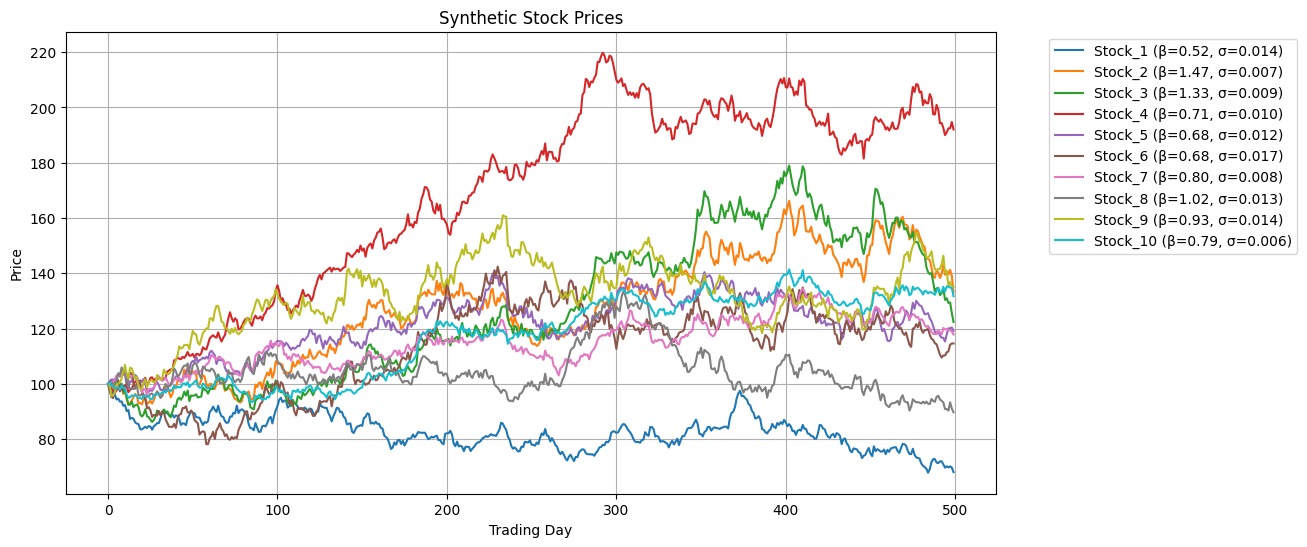

,Stock_1,Stock_2,Stock_3,Stock_4,Stock_5,Stock_6,Stock_7,Stock_8,Stock_9,Stock_10
0,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
1,97.934694,100.636391,100.786630,99.354544,101.033869,97.516709,100.261987,98.896156,99.480375,100.363246
2,96.469326,99.527894,100.971323,98.366555,101.638091,95.309313,100.214723,100.152013,95.619944,99.473089
3,97.138520,99.006996,100.970142,97.575202,101.556699,94.886798,100.930177,100.221333,95.841086,99.049136
4,96.191620,97.881580,100.574733,96.762377,101.505026,97.861696,101.157403,99.237563,96.941204,98.387493


In [18]:
########################################
# (a) Generate synthetic stock prices
########################################
np.random.seed(42)  # to make random numbers reproducible
N_stocks = 10
N_days = 500

# Set parameters

P0 = 100

mu = np.random.uniform(
    0.0001,
    0.0005,
    N_stocks
)

beta = np.random.uniform(
    0.5,
    1.5,
    N_stocks
)

sigma = np.random.uniform(
    0.005,
    0.02,
    N_stocks
)

# Generate common factor
# f_t ~ N(0, 0.01)

f = np.random.normal(
    0,
    0.01,
    N_days
)

# Generate prices using the DGP
# P_i,t = P_i,t-1 * exp(mu_i + beta_i * f_t + eps_i,t)

prices = np.zeros(
    (N_days, N_stocks)
)

prices[0] = P0

for t in range(1, N_days):

    eps = np.random.normal(
        0,
        sigma
    )

    prices[t] = prices[t-1] * np.exp(
        mu + beta*f[t] + eps
    )

stock_names = [
    f"Stock_{i+1}"
    for i in range(N_stocks)
]

prices_df = pd.DataFrame(
    prices,
    columns=stock_names
)

# Plot all 10 price series

plt.figure(figsize=(12,6))

for i, stock in enumerate(prices_df.columns):
    plt.plot(
        prices_df.index,
        prices_df[stock],
        label=f"{stock} (β={beta[i]:.2f}, σ={sigma[i]:.3f})"
    )

plt.title("Synthetic Stock Prices")
plt.xlabel("Trading Day")
plt.ylabel("Price")
plt.legend(
    bbox_to_anchor=(1.05,1),
    loc="upper left"
)

plt.grid(True)
plt.show()
prices_df.head()   # to ensure all stocks start from 100

### Observations

1. All stocks start from the same initial price (100), but their trajectories diverge over time due to differences in drift (μ), factor loadings (β), and idiosyncratic noise (σ).

2. Stock_2 (β = 1.47) and Stock_3 (β = 1.33) show stronger reactions to market movements and experience larger price swings compared to stocks with lower β values. This demonstrates that higher factor loadings increase sensitivity to the common market factor.

3. Stock_1 (β = 0.52) shows relatively weaker participation in market-wide movements and ends significantly lower than most other stocks, illustrating the effect of a smaller factor loading.

4. Despite having similar market exposure, stocks do not follow identical paths because each stock is affected by its own idiosyncratic noise term (epsilon_{i,t}).

5. The widening gap between the best-performing and worst-performing stocks over time highlights how small differences in μ, β, and σ accumulate through exponential compounding.

### Part b

In [19]:
########################################
# (b) Compute log returns
########################################

def compute_log_returns(prices):

    # returns shape:
    # (N_days-1, N_stocks)

    log_returns = np.log(
        prices[1:] / prices[:-1]
    )

    return log_returns


returns = compute_log_returns(prices)

returns_df = pd.DataFrame(
    returns,
    columns=stock_names
)

returns_df.head()
#print(f"Returns shape: {returns_df.shape}")

,Stock_1,Stock_2,Stock_3,Stock_4,Stock_5,Stock_6,Stock_7,Stock_8,Stock_9,Stock_10
0,-0.020869,0.006344,0.007836,-0.006475,0.010286,-0.025146,0.002616,-0.011100,-0.005210,0.003626
1,-0.015076,-0.011076,0.001831,-0.009994,0.005963,-0.022896,-0.000472,0.012619,-0.039579,-0.008909
2,0.006913,-0.005247,-0.000012,-0.008077,-0.000801,-0.004443,0.007114,0.000692,0.002310,-0.004271
3,-0.009796,-0.011432,-0.003924,-0.008365,-0.000509,0.030871,0.002249,-0.009864,0.011413,-0.006702
4,-0.019004,0.020557,0.007521,0.009845,0.013010,0.040948,0.017634,0.016642,0.029120,0.002443


###Why returns not prices?
PCA requires stationary data. Prices are non-stationary — they trend upward
over time, meaning their mean and variance change with time. This violates the
assumptions of PCA, which treats the data as draws from a fixed distribution.

Log returns, defined as r_t = ln(P_t / P_{t-1}), are approximately stationary, they fluctuate around a constant mean with stable variance. PCA on returns
therefore captures genuine co-movement structure rather than spurious
correlations driven by shared price trends.

### Part c

In [20]:
########################################
# (c) Correlation and Covariance matrices
########################################

# Compute correlation matrix

corr_matrix = returns_df.corr()

# Compute covariance matrix

cov_matrix = returns_df.cov()

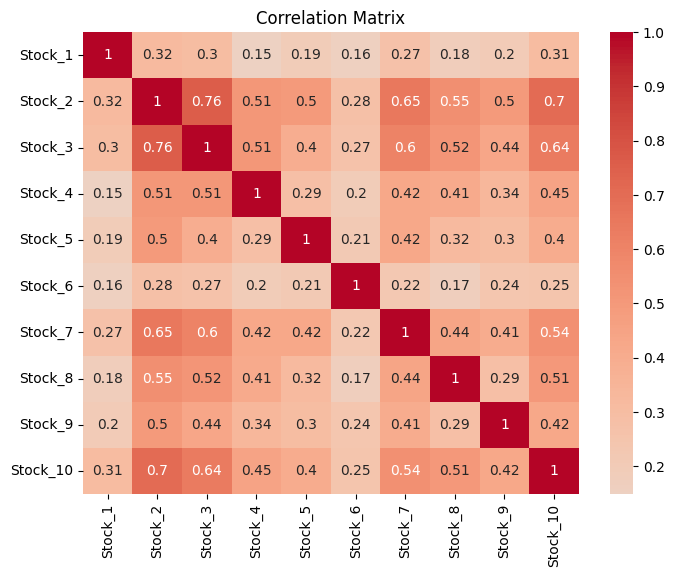

In [21]:
#correlation heatmap
plt.figure(figsize=(8,6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix")
plt.show()

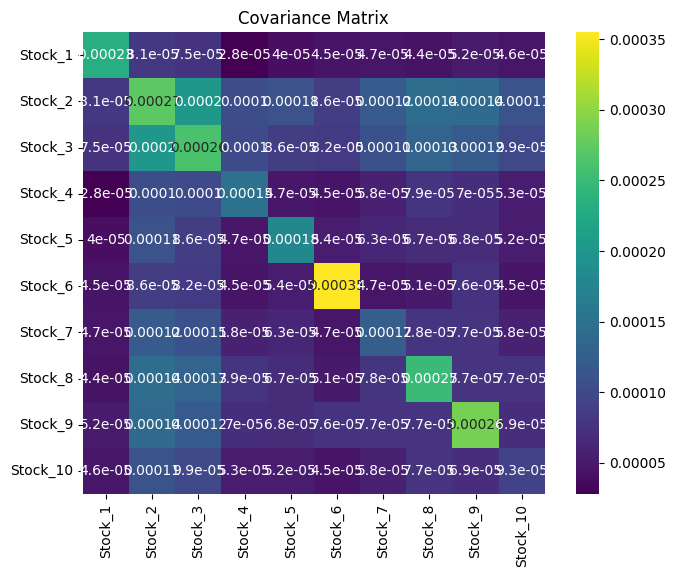

In [22]:
# covariance heatmap
plt.figure(figsize=(8,6))

sns.heatmap(
    cov_matrix,
    annot=True,
    cmap="viridis",
    square=True

)

plt.title("Covariance Matrix")
plt.show()

In [23]:
# Highest & Lowest Correlation Pair
corr_copy = corr_matrix.copy()

np.fill_diagonal(
    corr_copy.values,
    np.nan
)

max_pair = corr_copy.stack().idxmax()
max_value = corr_copy.stack().max()

min_pair = corr_copy.stack().idxmin()
min_value = corr_copy.stack().min()

print("Highest Correlation Pair:")
print(max_pair)
print("Correlation =", round(max_value,4))

print()

print("Lowest Correlation Pair:")
print(min_pair)
print("Correlation =", round(min_value,4))

Highest Correlation Pair:
('Stock_2', 'Stock_3')
Correlation = 0.7586

Lowest Correlation Pair:
('Stock_1', 'Stock_4')
Correlation = 0.1484


### Observations
1. All correlations are positive, which is expected — all stocks share the same common market factor f_t, so they tend to move together.
2. Stock_2 and Stock_3 have the highest correlation (0.76), suggesting they have similar factor loadings β, meaning the common factor affects them almost equally.
3. Stock_1 and Stock_4 have the lowest correlation (0.15), indicating their returns are driven more by idiosyncratic noise than by the shared factor.
4. The covariance matrix shows Stock_6 has the highest variance (brightest diagonal element), consistent with it having the highest σ drawn from U(0.005, 0.02).


### Part d

In [24]:
########################################
# (d) Standardize returns
########################################

def standardize_returns(returns):

    scaler = StandardScaler()

    standardized_returns = scaler.fit_transform(
        returns
    )

    return standardized_returns, scaler


standardized_returns, scaler = standardize_returns(
    returns
)

print("Mean of standardized returns:")
print(np.mean(
    standardized_returns,
    axis=0
))

print()

print("Standard deviation of standardized returns:")
print(np.std(
    standardized_returns,
    axis=0
))

Mean of standardized returns:
[ 1.11244792e-17 -4.00481251e-17 -4.00481251e-18 -7.34215628e-17
 -2.53638126e-17  4.35106193e-17  3.78232293e-17 -1.95790834e-17
  8.67709378e-18  3.02585834e-17]

Standard deviation of standardized returns:
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


/tmp/ipykernel_568/428394262.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


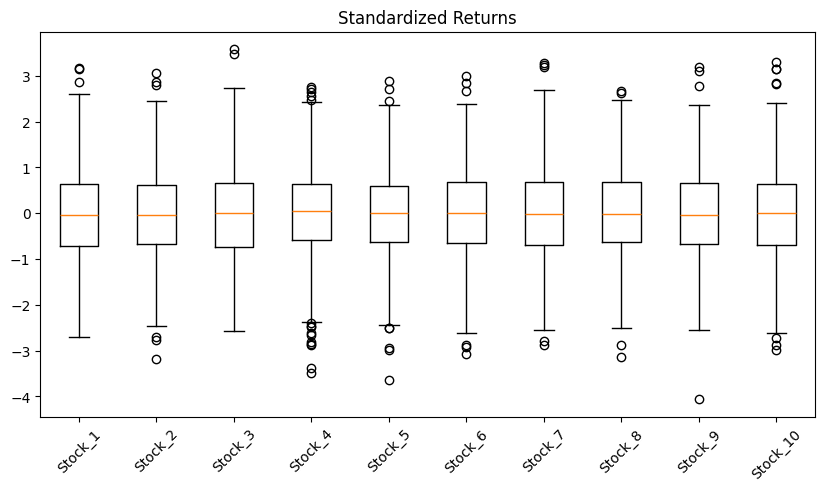

In [25]:
plt.figure(figsize=(10,5))

plt.boxplot(
    standardized_returns,
    labels=stock_names
)

plt.title(
    "Standardized Returns"
)

plt.xticks(rotation=45)

plt.show()

### Observations from Standardized Returns

1. The median return of each stock is close to zero, confirming successful mean centering.
2. The spreads of the boxplots are similar across all stocks, indicating that the returns have been scaled to unit variance.
3. A few extreme observations remain visible as outliers, showing that standardization rescales the data but does not remove unusual return events.


### Why standardization matters

Stocks can have significantly different volatilities.

Without standardization, highly volatile stocks dominate the covariance matrix and therefore dominate the principal components.

Standardization transforms each stock's return series to zero mean and unit variance, ensuring all stocks contribute equally to PCA.

If standardization is skipped:

- High-volatility stocks receive larger weights.
- PCA becomes volatility-driven.
- Important correlation structures may be obscured.

### Part e
#### Observations
1. The synthetic data successfully captures both systematic and idiosyncratic risk.
2. Price non-stationarity confirmed as raw prices drifted significantly from P₀ = 100 over 500 days due to compounding drift (μ) and factor exposure (β). This confirms why PCA must be applied to log returns rather than prices directly.
3. The correlation matrix reveals the common market factor through widespread positive correlations.
4. Standardization prevents high-volatility stocks from dominating the analysis.
5. The dataset resembles realistic financial markets where common factors drive asset co-movement while firm-specific noise introduces dispersion.
